# 07 — VAE-LSTM: Variational Autoencoder with LSTM for Battery Health (v3)

## v3 Improvements
- **Cross-battery split** (no data leakage)
- **18 features** per timestep (6 new physics-informed features)

## Architecture
- **Encoder:** 2-layer Bi-LSTM → μ, log σ² (latent_dim=16)
- **Reparameterization:** z = μ + σ · ε, ε ~ N(0,1)
- **Decoder:** 2-layer LSTM reconstructing input sequences
- **Health Head:** MLP mapping z → SOH prediction
- **Loss:** Reconstruction + β·KL divergence (β annealing) + SOH prediction loss

## Applications
1. SOH prediction from latent health embeddings
2. Anomaly detection via reconstruction error (3σ threshold)
3. Latent space visualization (UMAP)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models.deep.vae_lstm import VAE_LSTM, vae_loss, train_vae, detect_anomalies, BetaScheduler
from src.evaluation.metrics import regression_metrics, tolerance_accuracy
from src.utils.plotting import save_fig
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE, DROPOUT,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
plt.style.use("seaborn-v0_8-whitegrid")

# v3 paths
v3 = get_version_paths('v3')
ensure_version_dirs('v3')

Device: cuda
PyTorch: 2.6.0+cu124


{'root': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3'),
 'models_classical': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/classical'),
 'models_deep': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/deep'),
 'models_ensemble': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/ensemble'),
 'scalers': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/scalers'),
 'figures': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/figures'),
 'results': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/results'),
 'logs': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/logs')}

## 1. Load Data

In [2]:
V3_FEATURES = v3["root"] / "features"
data = np.load(str(V3_FEATURES / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

# ── v3 FIX: Cross-battery grouped split ──
unique_bids = np.unique(bids)
rng = np.random.RandomState(42)
shuffled = unique_bids.copy()
rng.shuffle(shuffled)
n_train = max(1, int(len(shuffled) * 0.8))
train_bats = set(shuffled[:n_train])
test_bats = set(shuffled[n_train:])

train_mask = np.isin(bids, list(train_bats))
test_mask = np.isin(bids, list(test_bats))

X_train, y_train = X_multi[train_mask], y_multi[train_mask]
X_test, y_test = X_multi[test_mask], y_multi[test_mask]
bids_test = bids[test_mask]

from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Overlap: {train_bats & test_bats if train_bats & test_bats else 'NONE ✓'}")

Train: (1444, 32, 18) | Test: (290, 32, 18)
Overlap: NONE ✓


## 2. Build & Train VAE-LSTM

In [3]:
vae = VAE_LSTM(
    input_dim=n_feat, seq_len=seq_len, hidden_dim=128,
    latent_dim=16, n_layers=2, dropout=DROPOUT,
)
print(f"VAE-LSTM params: {sum(p.numel() for p in vae.parameters()):,}")

history = train_vae(
    vae, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=1e-3,
    device=device, patience=EARLY_STOP_PATIENCE,
)
best_epoch = len(history["val_losses"]) - EARLY_STOP_PATIENCE
epochs_trained = len(history["val_losses"])
print(f"Trained {epochs_trained} epochs, best ~ epoch {best_epoch}")
torch.save(vae.state_dict(), str(v3["models_deep"] / "vae_lstm.pt"))

VAE-LSTM params: 826,931
Trained 60 epochs, best ~ epoch 40


## 3. SOH Prediction from Latent Space

In [4]:
vae.eval()
with torch.no_grad():
    out = vae(X_test_t.to(device))
    soh_pred = out["health_pred"].cpu().numpy()
    mu_test = out["mu"].cpu().numpy()

metrics = regression_metrics(y_test, soh_pred)
metrics["tol_2pct"] = tolerance_accuracy(y_test, soh_pred, 2.0)
print("VAE-LSTM SOH Prediction:")
print(f"  MAE  = {metrics['MAE']:.4f}")
print(f"  RMSE = {metrics['RMSE']:.4f}")
print(f"  R²   = {metrics['R2']:.4f}")
print(f"  MAPE = {metrics['MAPE']:.2f}%")
print(f"  Tol.Acc (±2%) = {metrics['tol_2pct']:.2%}")

VAE-LSTM SOH Prediction:
  MAE  = 4.3620
  RMSE = 6.7719
  R²   = 0.8756
  MAPE = 7.70%
  Tol.Acc (±2%) = 25.86%


## 4. Anomaly Detection
Reconstruction error exceeding mean + 3σ flags anomalous cycles.

Threshold (mean + 3σ): 2.839487
Anomalies detected: 0 / 290 (0.00%)
Mean recon error (train): 0.887766 ± 0.650574
Mean recon error (test):  1.059734 ± 0.542438


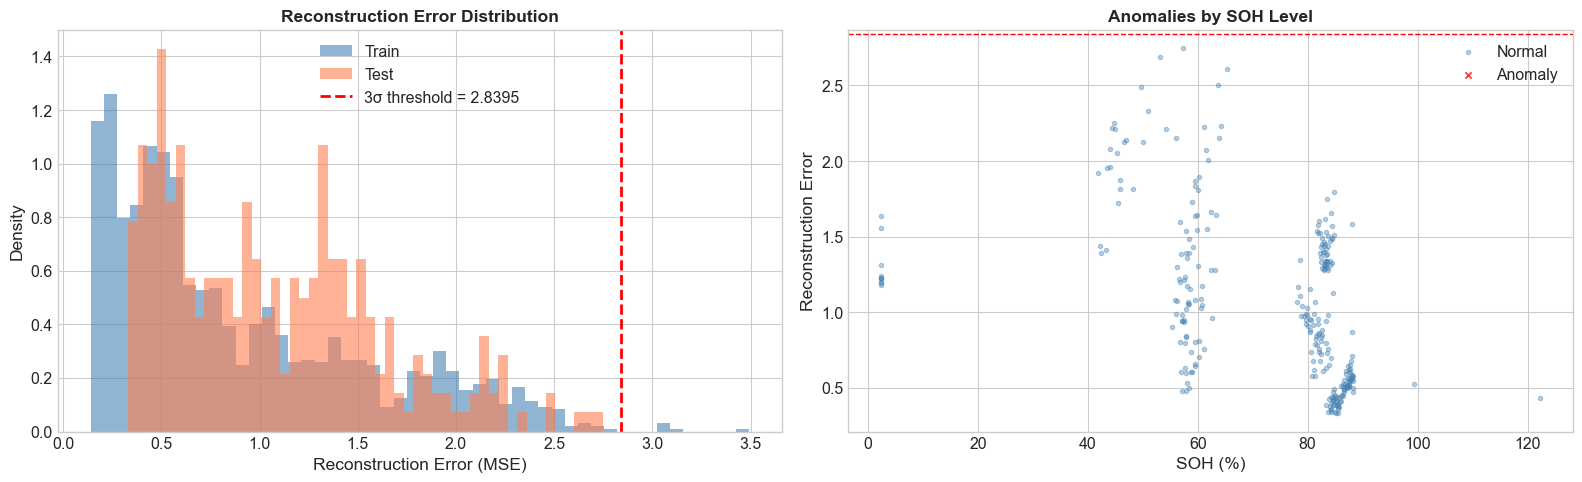

In [5]:
# Get reconstruction errors for training set (to fit threshold)
vae.eval()
with torch.no_grad():
    out_train = vae(X_train_t.to(device))
    recon_train = torch.mean((X_train_t.to(device) - out_train["recon"]) ** 2, dim=(1, 2)).cpu().numpy()
    
    out_test = vae(X_test_t.to(device))
    recon_test = torch.mean((X_test_t.to(device) - out_test["recon"]) ** 2, dim=(1, 2)).cpu().numpy()

threshold = recon_train.mean() + 3 * recon_train.std()
anomalies = recon_test > threshold

print(f"Threshold (mean + 3σ): {threshold:.6f}")
print(f"Anomalies detected: {anomalies.sum()} / {len(anomalies)} ({anomalies.mean():.2%})")
print(f"Mean recon error (train): {recon_train.mean():.6f} ± {recon_train.std():.6f}")
print(f"Mean recon error (test):  {recon_test.mean():.6f} ± {recon_test.std():.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].hist(recon_train, bins=50, alpha=0.6, label="Train", density=True, color="steelblue")
axes[0].hist(recon_test, bins=50, alpha=0.6, label="Test", density=True, color="coral")
axes[0].axvline(x=threshold, color="red", linestyle="--", linewidth=2, label=f"3σ threshold = {threshold:.4f}")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Density")
axes[0].set_title("Reconstruction Error Distribution", fontweight="bold")
axes[0].legend()

# Anomalies vs SOH
axes[1].scatter(y_test[~anomalies], recon_test[~anomalies], s=10, alpha=0.4, label="Normal", color="steelblue")
axes[1].scatter(y_test[anomalies], recon_test[anomalies], s=20, alpha=0.8, label="Anomaly", color="red", marker="x")
axes[1].axhline(y=threshold, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("SOH (%)")
axes[1].set_ylabel("Reconstruction Error")
axes[1].set_title("Anomalies by SOH Level", fontweight="bold")
axes[1].legend()

plt.tight_layout()
save_fig(fig, "v3_vae_anomaly_detection", directory=v3["figures"])
plt.show()

## 5. Latent Space Visualization (UMAP)

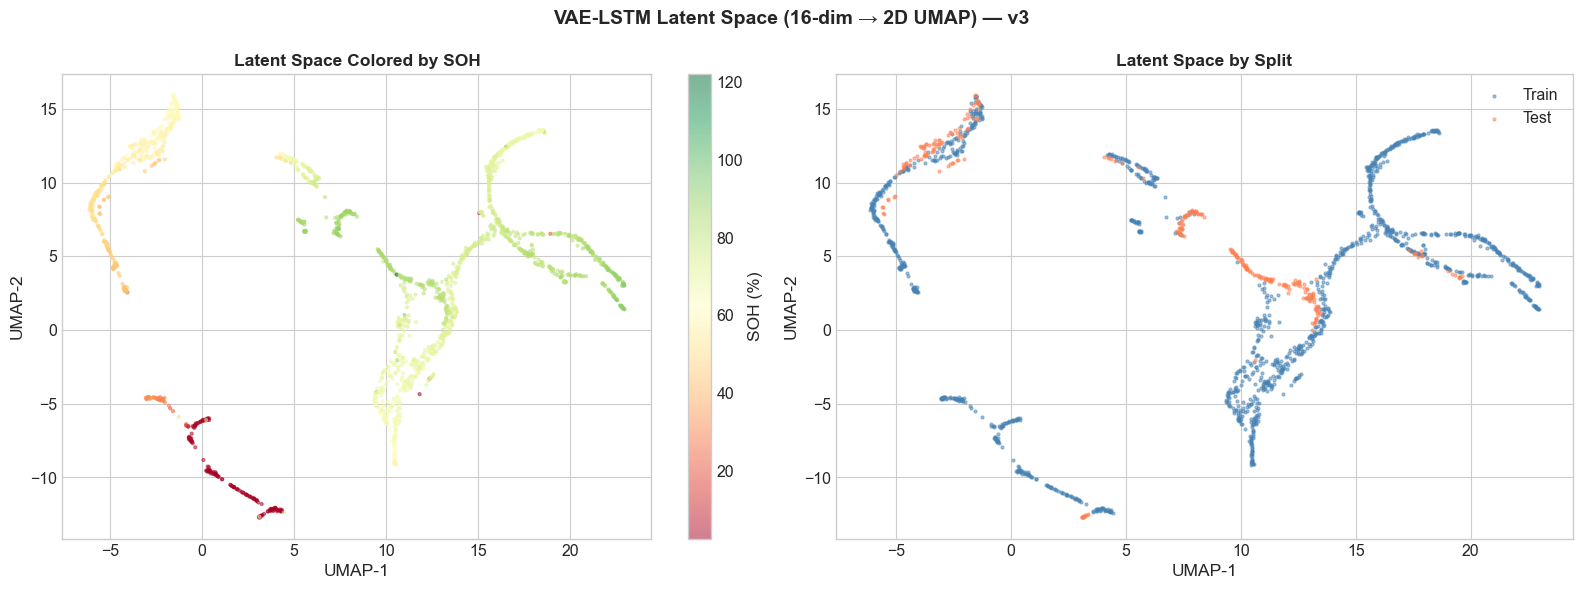

In [6]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed — skipping UMAP visualization")

if HAS_UMAP:
    # Get all latent vectors
    vae.eval()
    with torch.no_grad():
        out_all = vae(torch.FloatTensor(
            np.vstack([X_train, X_test])
        ).to(device))
        mu_all = out_all["mu"].cpu().numpy()

    y_all = np.concatenate([y_train, y_test])
    split_labels = np.array(["Train"] * len(y_train) + ["Test"] * len(y_test))

    # UMAP 2D
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
    z_2d = reducer.fit_transform(mu_all)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Color by SOH
    sc = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=y_all, cmap="RdYlGn", s=5, alpha=0.5)
    plt.colorbar(sc, ax=axes[0], label="SOH (%)")
    axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
    axes[0].set_title("Latent Space Colored by SOH", fontweight="bold")

    # Color by split
    colors = {"Train": "steelblue", "Test": "coral"}
    for label in ["Train", "Test"]:
        mask = split_labels == label
        axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], s=5, alpha=0.5,
                        label=label, color=colors[label])
    axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
    axes[1].set_title("Latent Space by Split", fontweight="bold")
    axes[1].legend()

    plt.suptitle("VAE-LSTM Latent Space (16-dim → 2D UMAP) — v3", fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "v3_vae_latent_umap", directory=v3["figures"])
    plt.show()
else:
    print("Skipping UMAP — install with: pip install umap-learn")

## 6. Training Curves & Actual vs Predicted

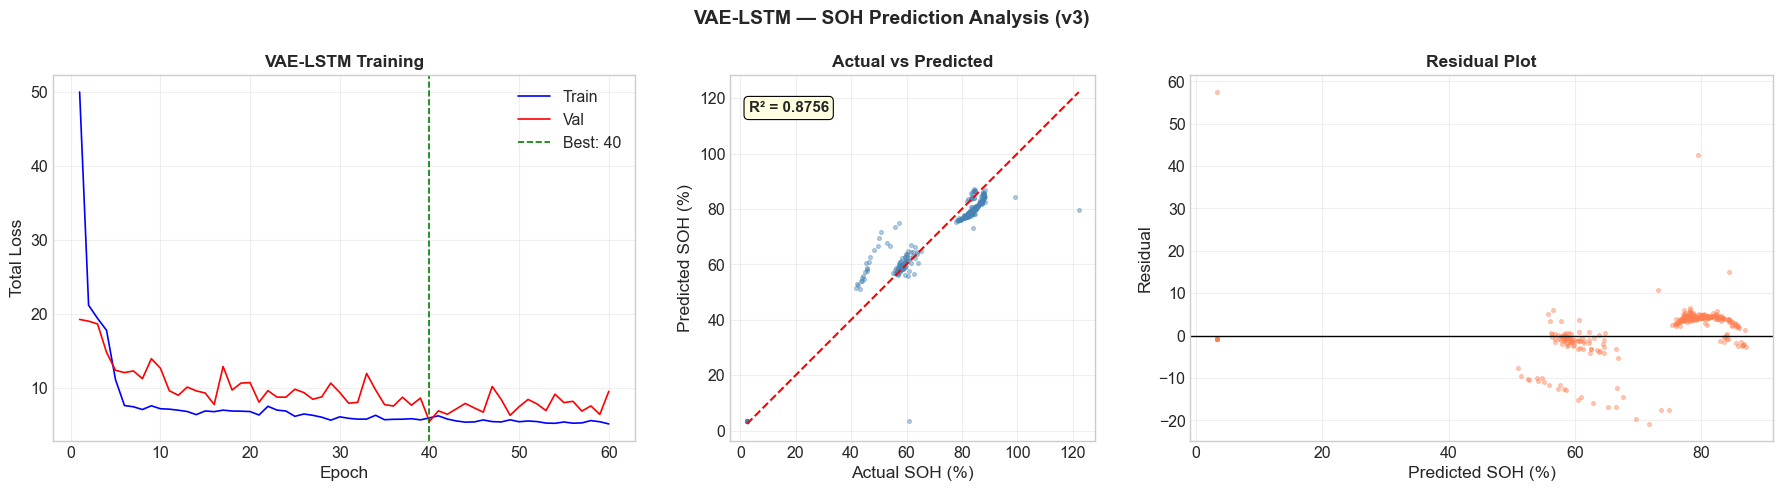

Results saved to v3.
Raw VAE predictions saved for ensemble & evaluation.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
epochs_range = range(1, len(history["train_losses"]) + 1)
axes[0].plot(epochs_range, history["train_losses"], "b-", label="Train")
axes[0].plot(epochs_range, history["val_losses"], "r-", label="Val")
axes[0].axvline(x=best_epoch, color="green", linestyle="--", label=f"Best: {best_epoch}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Total Loss")
axes[0].set_title("VAE-LSTM Training", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test, soh_pred, s=8, alpha=0.4, c="steelblue")
lims = [min(y_test.min(), soh_pred.min()), max(y_test.max(), soh_pred.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5)
axes[1].annotate(f"R² = {metrics['R2']:.4f}", xy=(0.05, 0.9), xycoords="axes fraction",
                 fontsize=11, fontweight="bold", bbox=dict(boxstyle="round", facecolor="lightyellow"))
axes[1].set_xlabel("Actual SOH (%)"); axes[1].set_ylabel("Predicted SOH (%)")
axes[1].set_title("Actual vs Predicted", fontweight="bold")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)

# Residuals
residuals = y_test - soh_pred
axes[2].scatter(soh_pred, residuals, s=8, alpha=0.4, c="coral")
axes[2].axhline(y=0, color="black", linewidth=1)
axes[2].set_xlabel("Predicted SOH (%)"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residual Plot", fontweight="bold"); axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE-LSTM — SOH Prediction Analysis (v3)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v3_vae_lstm_prediction", directory=v3["figures"])
plt.show()

# Save results
import json
with open(v3["results"] / "v3_vae_lstm_results.json", "w") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
print("Results saved to v3.")

# Save raw predictions for ensemble / CED in NB09
np.savez(
    v3["results"] / "v3_vae_predictions.npz",
    y_test=y_test,
    soh_pred=soh_pred,
    mu_test=mu_test,
    battery_ids_test=bids[test_mask] if "bids" in dir() else np.array([]),
)
print("Raw VAE predictions saved for ensemble & evaluation.")